# 01 · Cleaning — from raw transactions to analysable line items

**Purpose.** Every later number depends on which rows are kept. This notebook loads the raw *Online Retail II*
file, applies the four documented cleaning rules, shows exactly how many rows each rule removes, profiles what
is left, and saves `data/processed/lines.parquet` for the other notebooks.

All logic lives in `src/retention/core.py`; this notebook only calls it and looks at the results.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Markdown, display
from retention import config, core, plots

%matplotlib inline
pd.set_option("display.max_columns", 30, "display.width", 160, "display.float_format", "{:,.4f}".format)
WINDOW = 90   # repeat-purchase window (days) for the headline metric

## 1. Load the raw file

The dataset is located automatically (`config.find_dataset`) and read where it is — it is never moved or modified.

In [2]:
dataset = config.find_dataset()
raw = core.load_raw(dataset)
print("dataset:", config.relative_to_root(dataset))
print(f"{len(raw):,} rows x {raw.shape[1]} columns")
raw.head()

dataset: online_retail_II.csv
1,067,371 rows x 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0000,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0000,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0000,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0000,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0000,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


In [3]:
profile = pd.DataFrame({"dtype": raw.dtypes.astype(str), "nulls": raw.isna().sum(),
                        "null_share": raw.isna().mean(), "distinct": raw.nunique()})
profile

,dtype,nulls,null_share,distinct
Invoice,object,0,0.0000,53628
StockCode,object,0,0.0000,5304
Description,object,4382,0.0041,5655
Quantity,float64,0,0.0000,1057
InvoiceDate,datetime64[ns],0,0.0000,47635
Price,float64,0,0.0000,2807
CustomerID,float64,243007,0.2277,5942
Country,object,0,0.0000,43


`CustomerID` is the column that matters: rows without it are guest checkouts that cannot be followed over time,
so retention can only ever be measured on **identified customers** (trap 7).

## 2. Apply the cleaning rules

In order: drop rows with no `CustomerID` → drop cancellations (`C…`) and adjustments (`A…`) → drop `Quantity ≤ 0` or `Price ≤ 0` → drop non-product stock codes.

In [4]:
lines, log = core.clean(raw)
bounds = core.period_bounds(lines)
waterfall = core.waterfall_table(log)
waterfall.style.format({"RowsRemaining": "{:,.0f}", "RowsRemoved": "{:,.0f}", "PctOfRawRemoved": "{:.2%}",
                        "PctOfPreviousRemoved": "{:.2%}", "PctOfRawRemaining": "{:.2%}"}).hide(axis="index")

Step,RowsRemaining,RowsRemoved,PctOfRawRemoved,PctOfPreviousRemoved,PctOfRawRemaining
Raw rows,"1,067,371",0,0.00%,0.00%,100.00%
Has a CustomerID,"824,364","243,007",22.77%,22.77%,77.23%
Not a cancellation / adjustment,"805,620","18,744",1.76%,2.27%,75.48%
Quantity > 0 and Price > 0,"805,549",71,0.01%,0.01%,75.47%
Product stock code (final),"802,632","2,917",0.27%,0.36%,75.20%


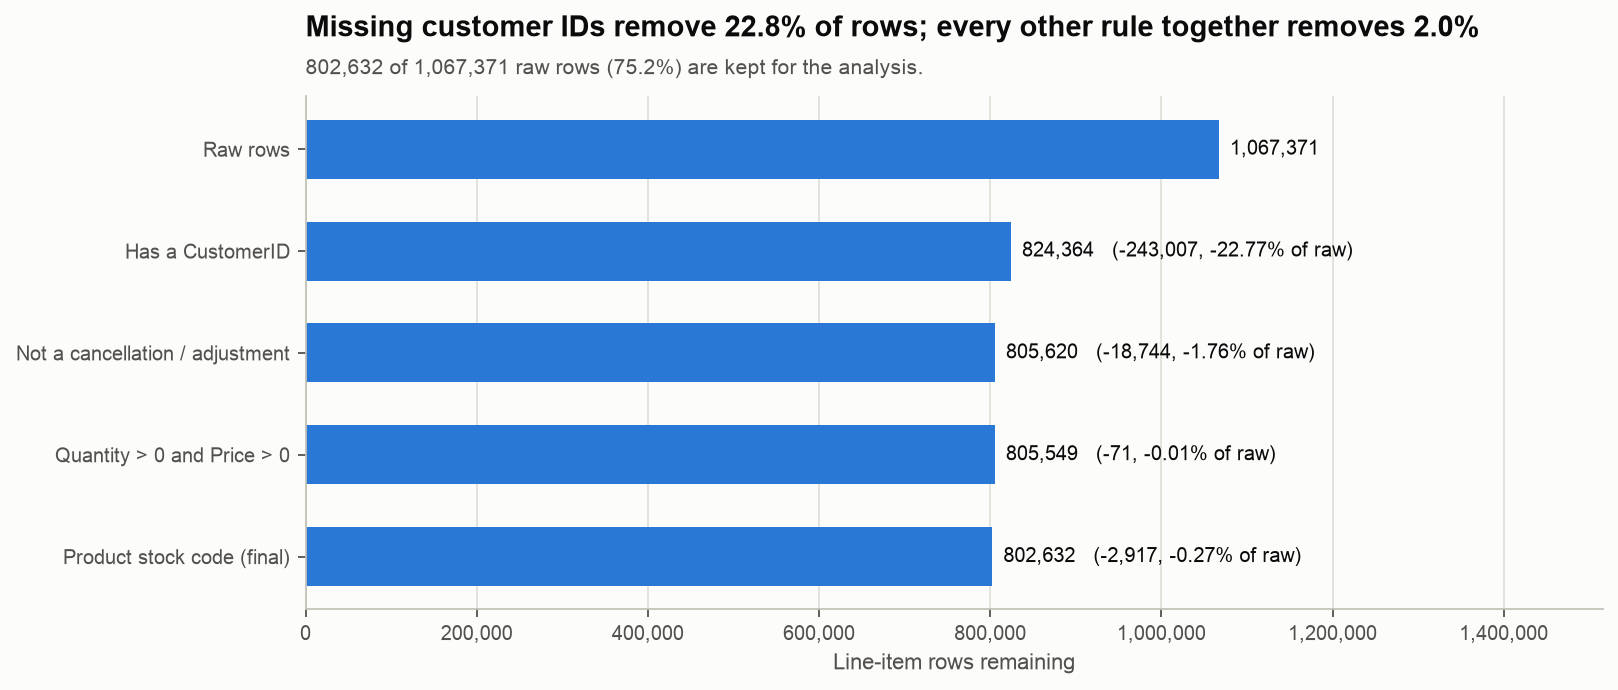

In [5]:
plots.cleaning_waterfall(waterfall)

In [6]:
missing = int(raw["CustomerID"].isna().sum())
display(Markdown(
    f"**Reading the waterfall.** {missing:,} rows ({missing / len(raw):.1%}) have no `CustomerID` - by far the "
    f"largest loss. Cancellations/adjustments remove {log['after_missing_customer'] - log['after_cancel_adjust']:,} "
    f"rows, bad quantity/price {log['after_cancel_adjust'] - log['after_qty_price']:,}, and non-product codes "
    f"{log['non_product_rows']:,}. **{log['after_non_product']:,} rows** remain "
    f"({log['after_non_product'] / log['raw_rows']:.1%} of raw)."))

**Reading the waterfall.** 243,007 rows (22.8%) have no `CustomerID` - by far the largest loss. Cancellations/adjustments remove 18,744 rows, bad quantity/price 71, and non-product codes 2,917. **802,632 rows** remain (75.2% of raw).

## 3. What the non-product rule removes (trap 4)

A real product code is five digits plus at most two letters. Everything else is postage, fees, manual adjustments,
samples or test rows. Because this is a judgement call, the table below shows exactly what is excluded, and
section 7 re-runs the headline metrics with these rows kept.

In [7]:
lines_all, log_all = core.clean(raw, drop_non_product=False)
non_product = core.non_product_breakdown(lines_all)
display(non_product.style.format({"Rows": "{:,.0f}", "Revenue": "£{:,.2f}", "Customers": "{:,.0f}",
                                  "RevenueShare": "{:.3%}"}))
print(f"{log['non_product_rows']:,} rows | {len(log['non_product_codes'])} distinct codes | "
      f"{log['non_product_revenue_share']:.2%} of revenue | "
      f"{log_all['customers'] - log['customers']} customers who only ever bought non-product lines are lost entirely")

,Rows,Revenue,Customers,RevenueShare
StockCode,,,,
POST,"1,838","£126,563.04",405,0.713%
M,709,"£152,340.57",438,0.859%
C2,253,"£12,796.00",45,0.072%
ADJUST,32,"£3,538.52",25,0.020%
BANK CHARGES,32,£465.00,19,0.003%
PADS,17,£0.02,15,0.000%
DOT,16,"£11,906.36",1,0.067%
TEST001,9,£225.00,2,0.001%
D,5,£397.89,5,0.002%


2,917 rows | 12 distinct codes | 1.74% of revenue | 26 customers who only ever bought non-product lines are lost entirely


## 4. Time boundaries — derived, never hard-coded

In [8]:
for k, v in bounds.items():
    print(f"{k:>20}: {v}")
display(Markdown(
    f"The data ends on **{bounds['data_end']:%d %b %Y}**, part-way through {bounds['last_month']}. The last "
    f"*complete* month is therefore **{bounds['last_complete_month']}** - retention cells after it are masked "
    f"rather than shown as zero (trap 3). The first month, **{bounds['first_month']}**, is left-censored: its "
    "'new' customers include long-standing ones (trap 1)."))

            data_end: 2011-12-09 12:50:00
         first_month: 2009-12
 last_complete_month: 2011-11
          last_month: 2011-12


The data ends on **09 Dec 2011**, part-way through 2011-12. The last *complete* month is therefore **2011-11** - retention cells after it are masked rather than shown as zero (trap 3). The first month, **2009-12**, is left-censored: its 'new' customers include long-standing ones (trap 1).

## 5. Profile of the cleaned data

In [9]:
orders = core.build_orders(lines)
customers = core.build_customers(orders, bounds)
pd.Series({"Date range": f"{log['date_min']}  ->  {log['date_max']}",
           "Line items": f"{len(lines):,}", "Orders (distinct invoices)": f"{log['invoices']:,}",
           "Customers": f"{log['customers']:,}", "Revenue (gross of returns)": f"£{log['revenue']:,.0f}",
           "Median orders per customer": f"{customers['Orders'].median():.0f}",
           "Mean orders per customer": f"{customers['Orders'].mean():.2f}",
           "Median order value": f"£{orders['Revenue'].median():,.2f}",
           "Mean order value": f"£{orders['Revenue'].mean():,.2f}"}, name="value").to_frame()

,value
Date range,2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Line items,"802,632"
Orders (distinct invoices),"36,594"
Customers,"5,852"
Revenue (gross of returns),"£17,434,450"
Median orders per customer,3
Mean orders per customer,6.25
Median order value,£304.65
Mean order value,£476.43


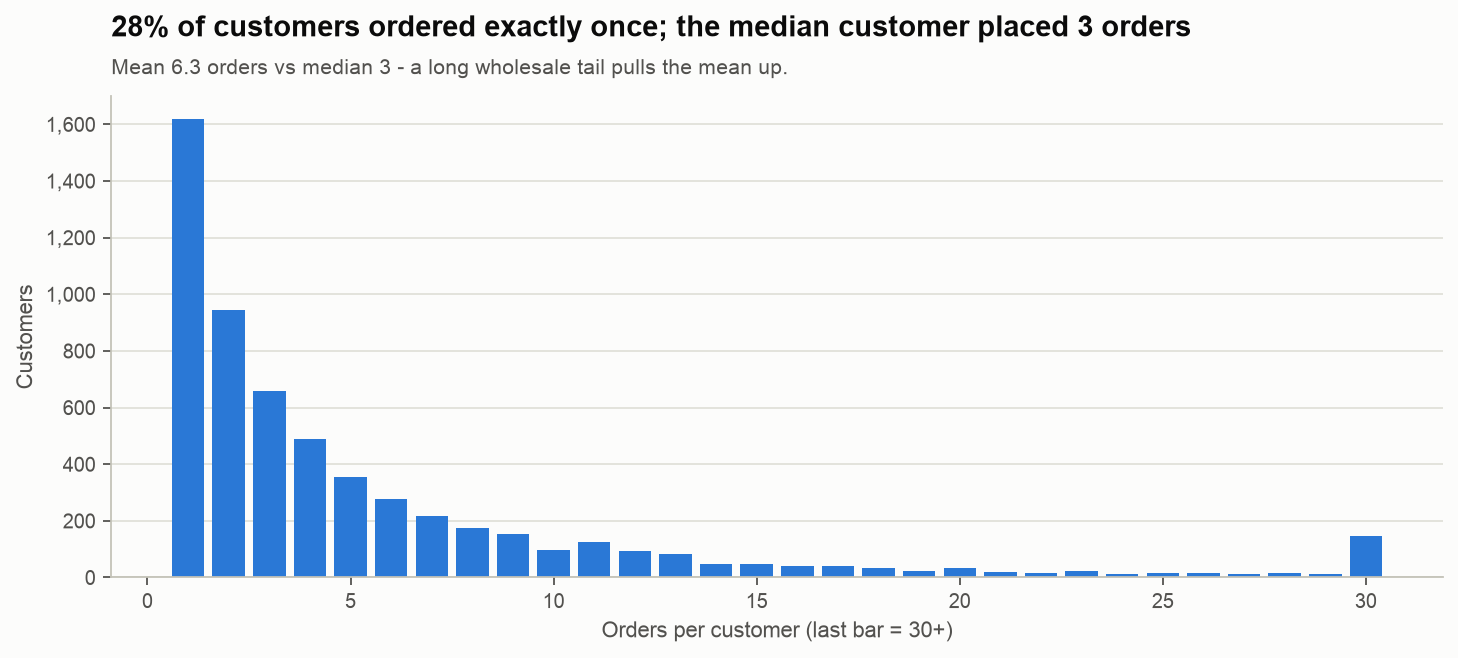

In [10]:
plots.orders_per_customer_hist(customers)

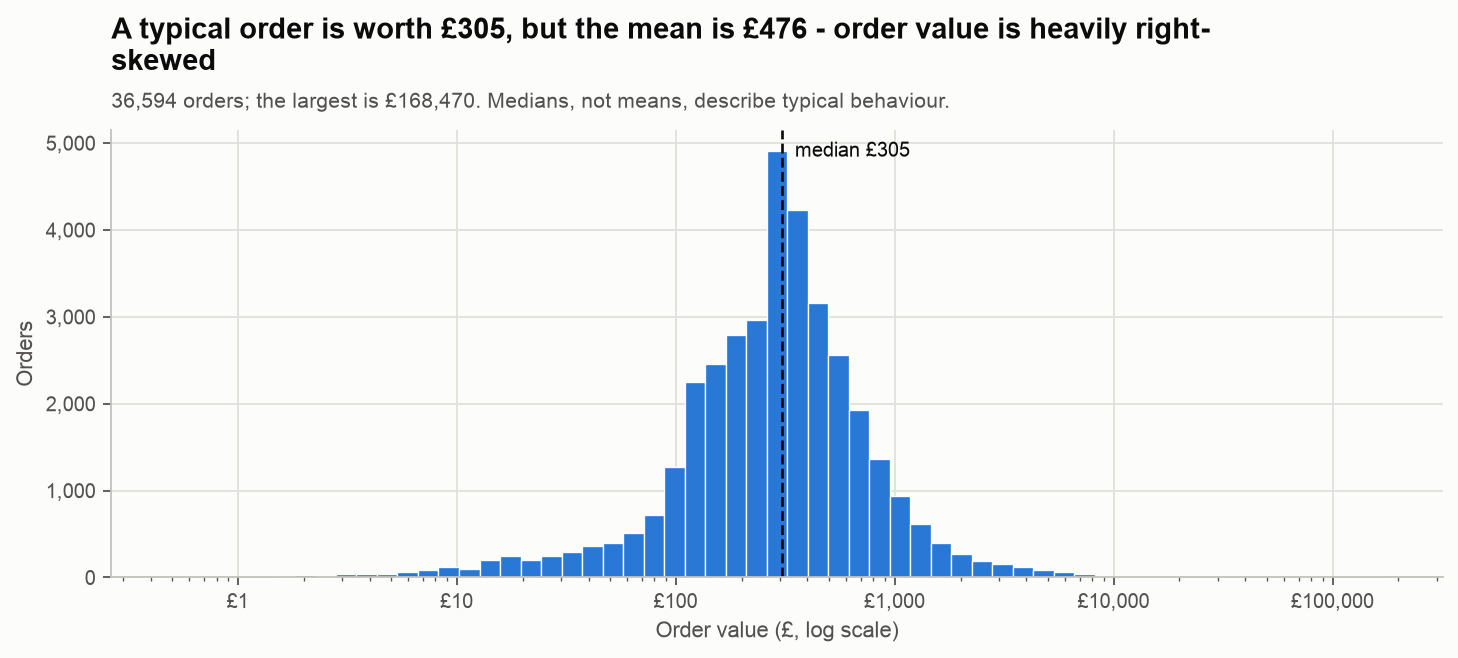

In [11]:
plots.order_value_hist(orders)

Both distributions have a long right tail: many of this retailer's customers are **wholesalers**. That is why the project reports medians for typical behaviour (trap 8).

,Customers,Orders,Revenue,CustomerShare
Country,,,,
United Kingdom,"5,334","33,361","£14,622,043",91.1%
Germany,107,754,"£389,624",1.8%
France,91,586,"£313,782",1.6%
Spain,36,141,"£98,117",0.6%
Belgium,27,154,"£61,069",0.5%
Portugal,23,83,"£48,088",0.4%
Netherlands,22,216,"£549,953",0.4%
Switzerland,21,78,"£92,127",0.4%
Sweden,19,98,"£86,079",0.3%


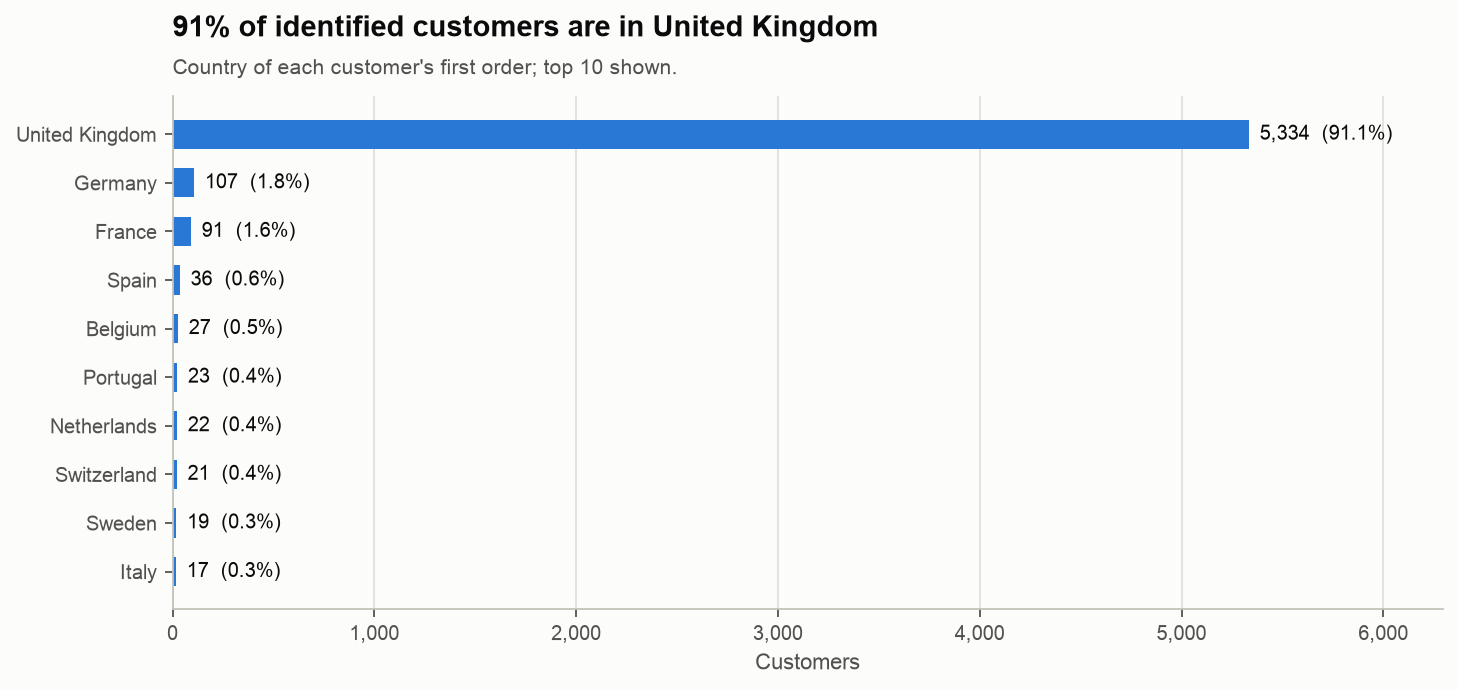

In [12]:
countries = core.top_countries(customers)
display(countries.style.format({"Customers": "{:,.0f}", "Orders": "{:,.0f}", "Revenue": "£{:,.0f}",
                                "CustomerShare": "{:.1%}"}))
plots.top_countries_bar(countries)

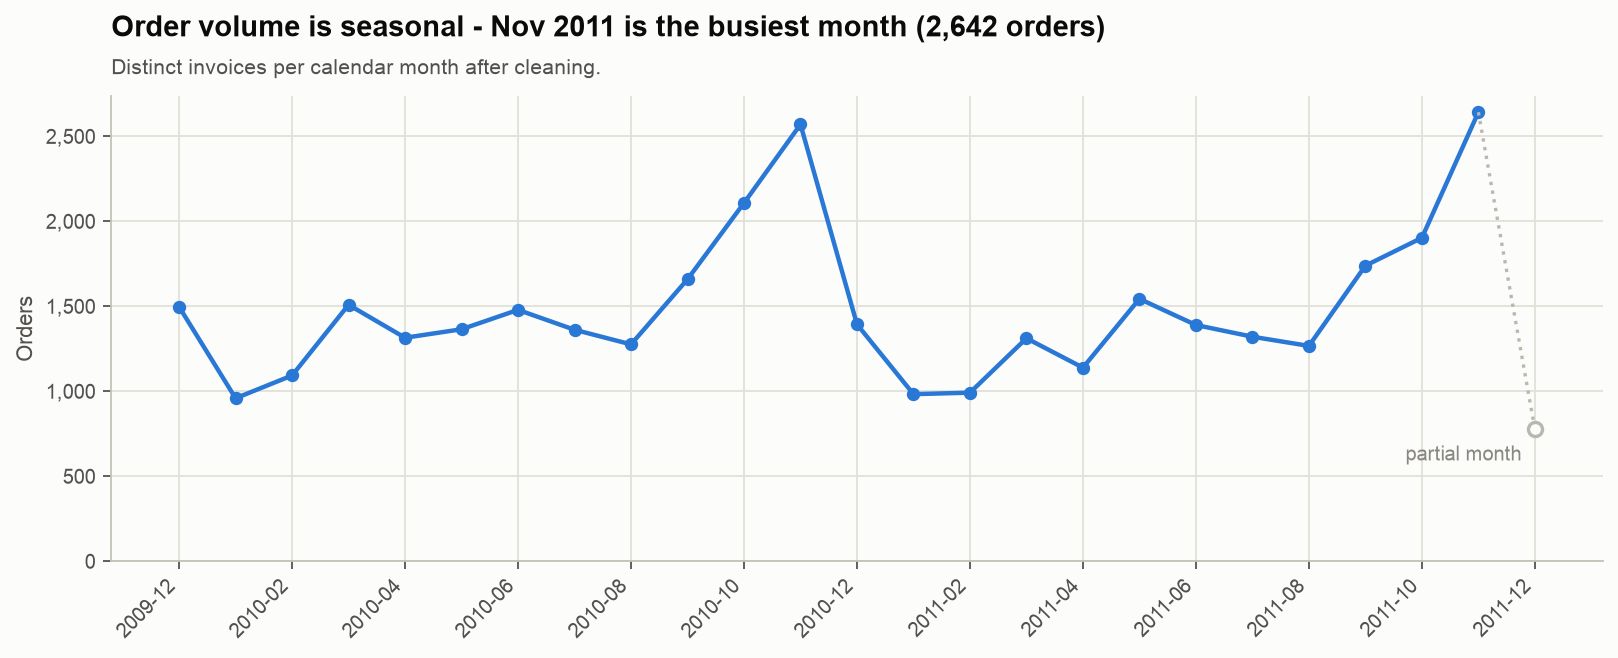

In [13]:
monthly = core.monthly_orders(orders)
plots.monthly_orders_line(monthly, bounds["last_complete_month"])

## 6. Save and assert

In [14]:
config.ensure_dirs()
lines.to_parquet(config.LINES_PARQUET, index=False)
print("saved", config.relative_to_root(config.LINES_PARQUET), f"({len(lines):,} rows)")

saved data/processed/lines.parquet (802,632 rows)


In [15]:
# Integrity checks on the cleaned line items
assert not lines["Invoice"].str.upper().str.startswith(("C", "A")).any(), "cancellation/adjustment left in"
assert (lines["Quantity"] > 0).all() and (lines["Price"] > 0).all(), "non-positive quantity or price left in"
assert lines["CustomerID"].notna().all(), "null CustomerID left in"
assert lines["StockCode"].str.match(core.PRODUCT_CODE_RE).all(), "non-product code left in"

# Acceptance numbers from PROJECT_PLAN.md section 6 (valid for the standard Online Retail II file)
EXPECTED = {"raw_rows": 1_067_371, "after_missing_customer": 824_364, "after_cancel_adjust": 805_620,
            "after_qty_price": 805_549, "after_non_product": 802_632, "invoices": 36_594, "customers": 5_852}
for key, value in EXPECTED.items():
    assert log[key] == value, f"{key}: got {log[key]:,}, expected {value:,}"
assert abs(log["revenue"] - 17_434_450) < 1, log["revenue"]
print("all cleaning assertions passed:", {k: f"{log[k]:,}" for k in EXPECTED})

all cleaning assertions passed: {'raw_rows': '1,067,371', 'after_missing_customer': '824,364', 'after_cancel_adjust': '805,620', 'after_qty_price': '805,549', 'after_non_product': '802,632', 'invoices': '36,594', 'customers': '5,852'}


## 7. Sensitivity check — does the non-product rule change the answer? (trap 4)

The headline metrics are recomputed with the non-product rows **kept**. If the like-for-like repeat rate moves
by more than 1 percentage point the choice matters and must be discussed; otherwise it is immaterial.

In [16]:
def headline_for(line_items, cleaning_log):
    b = core.period_bounds(line_items)
    o = core.build_orders(line_items)
    c = core.build_customers(o, b)
    return core.sensitivity_metrics(core.headline_metrics(o, c, b, WINDOW), cleaning_log["customers"],
                                    cleaning_log["revenue"])

sens = pd.DataFrame({"non-product dropped (used)": headline_for(lines, log),
                     "non-product kept": headline_for(lines_all, log_all)})
sens["difference"] = sens.iloc[:, 1] - sens.iloc[:, 0]
display(sens)
diff_pp = sens.loc["repeat_window_mean", "difference"] * 100
display(Markdown(
    f"Keeping the non-product rows moves repeat-within-{WINDOW}-days by **{diff_pp:+.2f} pp** "
    f"({'more' if abs(diff_pp) > 1 else 'less'} than the 1 pp threshold) - the choice is "
    f"**{'material' if abs(diff_pp) > 1 else 'immaterial'}** for the headline conclusions."))

,non-product dropped (used),non-product kept,difference
repeat_window_mean,0.4342,0.4398,0.0055
km_repeated_by_window,0.4737,0.4786,0.0050
median_days_to_second,57.0000,56.0000,-1.0000
month1_retention,0.2066,0.2084,0.0018
repeat_revenue_share,0.8629,0.8630,0.0001
customers,"5,852.0000","5,878.0000",26.0000
revenue,"17,434,449.9800","17,743,429.1780","308,979.1980"


Keeping the non-product rows moves repeat-within-90-days by **+0.55 pp** (less than the 1 pp threshold) - the choice is **immaterial** for the headline conclusions.